# DiffDock — Pose Distribution Analysis

Characterises the distribution of predicted poses for a single complex.
Change `RESULTS_DIR` to analyse any run.

In [1]:
import sys
sys.path.insert(0, '..')  # project root when running from notebooks/

from utils.distribution_analysis import (
    load_poses,
    compute_rmsd_matrix,
    cluster_poses,
    saturation_analysis,
    plot_rmsd_heatmap,
    torsion_rose_plots,
    view_poses_colored,
    run_full_analysis,
    compute_rmsd_to_crystal, 
    plot_confidence_vs_rmsd
)
import numpy as np
import matplotlib.pyplot as plt

/home/qf226/.conda/envs/diffdock/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
# ── Only cell you need to change per run ──────────────────────────────────
RESULTS_DIR = '../results/6d08_100samples/complex_0'
CRYSTAL_SDF = '../data/PDBBind_processed/6d08/6d08_ligand.sdf'
CLUSTER_CUTOFF = 5.0  # Angstroms — 2 Å is the docking benchmark cutoff (retrieval); 5 Å groups poses by region of protein surface
# ──────────────────────────────────────────────────────────────────────────

## 1. Load poses & compute pairwise RMSD

Uses `spyrmsd.rmsd.symmrmsd` — symmetry-corrected, so symmetric ligands are handled correctly.

In [18]:
poses = load_poses(RESULTS_DIR)
print(f"{len(poses)} poses loaded")
#for p in poses:
#    print(f"  rank{p.rank:2d}  confidence={p.confidence:.2f}")

100 poses loaded


In [19]:
rmsd_matrix = compute_rmsd_matrix(poses)
np.set_printoptions(precision=2, suppress=True)
#print("RMSD matrix (Å):")
#print(rmsd_matrix)

## 2. Clustering

Complete-linkage hierarchical clustering. The 2 Å cutoff used in docking benchmarks answers "is a pose near the crystal structure?" — a retrieval question. Here we ask a *distribution* question: how many distinct surface regions does DiffDock concentrate mass in? With typical inter-pose RMSDs of 10–40 Å, a 5 Å cutoff is more appropriate: it groups poses that are in the same general binding site/region of the protein surface. Cluster population ≈ mode weight.

In [5]:
cluster_labels, linkage_matrix = cluster_poses(rmsd_matrix, cutoff=CLUSTER_CUTOFF)
n_clusters = len(set(cluster_labels))
print(f"{n_clusters} cluster(s) at {CLUSTER_CUTOFF} Å cutoff")
for p, cl in zip(poses, cluster_labels):
    print(f"  rank{p.rank:2d}  conf={p.confidence:.2f}  cluster={cl}")

3 cluster(s) at 5.0 Å cutoff
  rank 1  conf=0.63  cluster=2
  rank 2  conf=0.59  cluster=2
  rank 3  conf=0.58  cluster=2
  rank 4  conf=0.58  cluster=2
  rank 5  conf=0.57  cluster=2
  rank 6  conf=0.57  cluster=2
  rank 7  conf=0.57  cluster=2
  rank 8  conf=0.57  cluster=1
  rank 9  conf=0.57  cluster=2
  rank10  conf=0.57  cluster=1
  rank11  conf=0.57  cluster=1
  rank12  conf=0.56  cluster=2
  rank13  conf=0.56  cluster=1
  rank14  conf=0.56  cluster=2
  rank15  conf=0.56  cluster=1
  rank16  conf=0.56  cluster=2
  rank17  conf=0.56  cluster=1
  rank18  conf=0.55  cluster=2
  rank19  conf=0.55  cluster=1
  rank20  conf=0.55  cluster=1
  rank21  conf=0.55  cluster=2
  rank22  conf=0.55  cluster=2
  rank23  conf=0.55  cluster=2
  rank24  conf=0.55  cluster=2
  rank25  conf=0.55  cluster=2
  rank26  conf=0.55  cluster=1
  rank27  conf=0.55  cluster=1
  rank28  conf=0.55  cluster=2
  rank29  conf=0.54  cluster=1
  rank30  conf=0.54  cluster=1
  rank31  conf=0.54  cluster=1
  rank32  

## 3. Saturation analysis

Mean pairwise RMSD of top-N poses vs. N. Plateau → most modes found. Still rising → more samples needed.

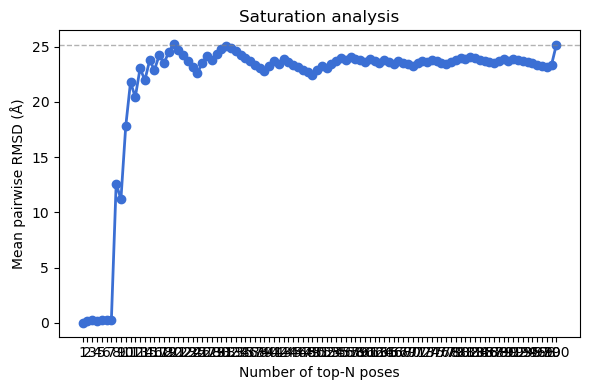

In [6]:
fig = saturation_analysis(poses, rmsd_matrix)
plt.show()

## 4. RMSD heatmap

Rows/columns reordered by dendrogram leaf order. Red lines = cluster boundaries.
Block structure → well-separated modes. Diffuse → broad unimodal distribution.

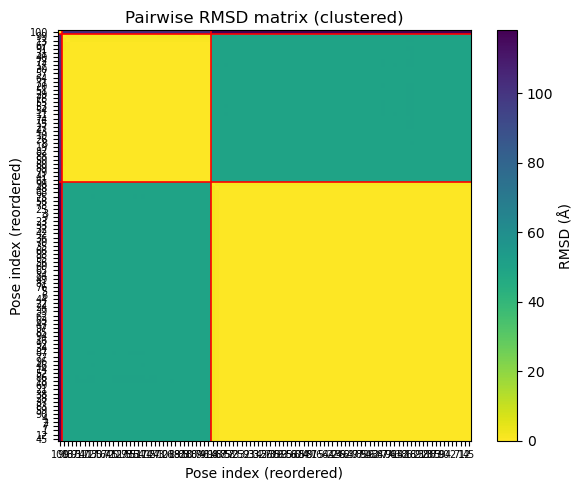

In [7]:
fig = plot_rmsd_heatmap(rmsd_matrix, labels=cluster_labels)
plt.show()

## 5. 3D viewer — coloured by confidence

Blue = high confidence, red = low confidence.

In [8]:
viewer = view_poses_colored(
    poses,
    results_dir=RESULTS_DIR,
    color_by='confidence',
)
viewer.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 6. 3D viewer — coloured by cluster

In [9]:
viewer = view_poses_colored(
    poses,
    results_dir=RESULTS_DIR,
    color_by='cluster',
    cluster_labels=cluster_labels,
)
viewer.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 7. Torsional analysis

Circular histogram per rotatable bond. CV = circular variance (0 = perfectly constrained, 1 = uniform).

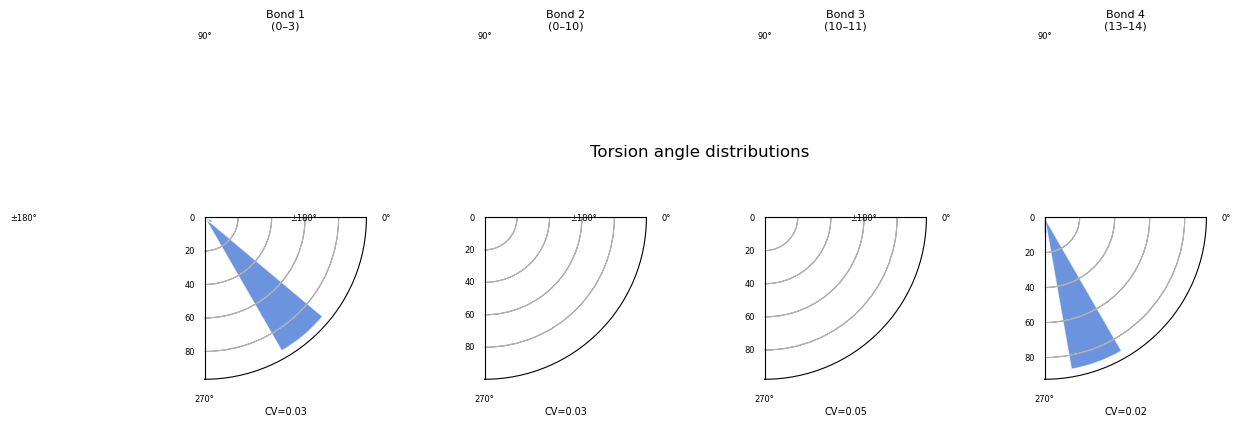

In [10]:
fig = torsion_rose_plots(poses)
plt.show()

## One-shot: `run_full_analysis`

Convenience wrapper — runs everything above in one call.

In [11]:
# results = run_full_analysis(RESULTS_DIR, cutoff=CLUSTER_CUTOFF)
results['saturation_fig'].show()
results['heatmap_fig'].show()
results['torsion_fig'].show()

NameError: name 'results' is not defined

## 8. Confidence vs. crystal RMSD — 6d08

Compares each predicted pose to the crystallographic ground truth (PDBBind).
A negative Spearman ρ means the confidence model correctly ranks more accurate poses higher.

In [23]:
RESULTS_DIR = '../results/test_run/1a0q'
CRYSTAL_SDF = '../data/1a0q/1a0q_ligand.sdf'

Poses: 10
RMSD to crystal — min: 3.96 Å  median: 4.56 Å  max: 8.18 Å
Poses < 2 Å: 0  |  < 5 Å: 8


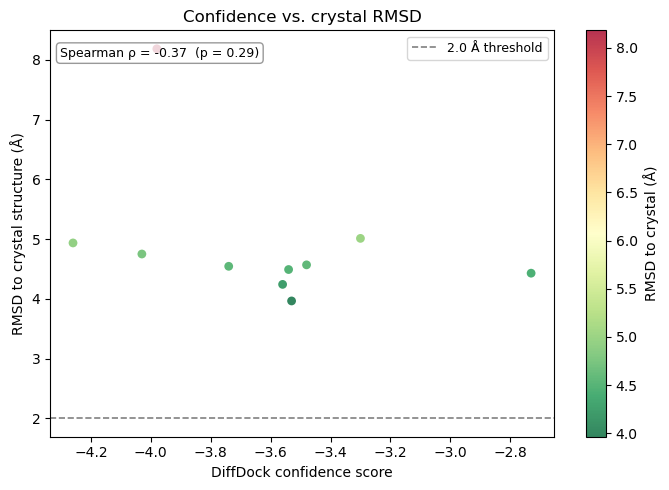

In [24]:
from utils.distribution_analysis import compute_rmsd_to_crystal, plot_confidence_vs_rmsd


poses = load_poses(RESULTS_DIR)
rmsds = compute_rmsd_to_crystal(CRYSTAL_SDF, poses)

print(f"Poses: {len(poses)}")
print(f"RMSD to crystal — min: {rmsds.min():.2f} Å  "
      f"median: {np.median(rmsds):.2f} Å  "
      f"max: {rmsds.max():.2f} Å")
print(f"Poses < 2 Å: {(rmsds < 2).sum()}  |  < 5 Å: {(rmsds < 5).sum()}")

fig = plot_confidence_vs_rmsd(poses, rmsds)
plt.show()